In [114]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from sentence_transformers import SentenceTransformer
random_state=24

## MRC Dataset

In [2]:

# Load val file
with open("MRC Dataset/val.json", "r", encoding="utf-8") as f:
    data = json.load(f)

records = []

for article in data["data"]:
    for paragraph in article["paragraphs"]:
        context = paragraph.get("context", "")

        for qa in paragraph["qas"]:
            question = qa["question"]

            if qa["answers"]:
                answer = qa["answers"][0]["text"]
            else:
                answer = None

            records.append({
                "question": question,
                "answer": answer,
                "context": context
            })

df_mrc_val = pd.DataFrame(records)

df_mrc_val.head()

,question,answer,context
0,ما هي غابات ميومبو وأين توجد؟\n,هي أراضي عُشبية استوائية وشبه استوائية بيولوجي...,غابات ميومبو هي أراضي عُشبية استوائية وشبه است...
1,ما هي المناطق البيئية الأربعة التي تميز غابات ...,يُمكن تصنيف غابات ميومبو على أنها جافةً أو رط...,غابات ميومبو هي أراضي عُشبية استوائية وشبه است...
2,كيف يتم تصنيف غابات ميومبو إلى أغاب ورطبة؟\n,هي تلك التي تستقبل أكثر من 1000 مم سنويًا لهطو...,غابات ميومبو هي أراضي عُشبية استوائية وشبه است...
3,كيف تساعد غابات ميومبو في توفير سُبل العيش للس...,الذين يعتمدون على الموارد المتاحة من الغابات,غابات ميومبو هي أراضي عُشبية استوائية وشبه است...
4,ما هي المنتجات غير الخشبية التي يمكن العثور عل...,مثل الفاكهة والعسل وعلف الماشية وحطب الوقود,غابات ميومبو هي أراضي عُشبية استوائية وشبه است...


In [3]:

# Load train file
with open("MRC Dataset/train.json", "r", encoding="utf-8") as f:
    data = json.load(f)

records = []

for article in data["data"]:
    for paragraph in article["paragraphs"]:
        context = paragraph.get("context", "")

        for qa in paragraph["qas"]:
            question = qa["question"]

            if qa["answers"]:
                answer = qa["answers"][0]["text"]
            else:
                answer = None

            records.append({
                "question": question,
                "answer": answer,
                "context": context
            })

df_mrc_train = pd.DataFrame(records)

df_mrc_train.head()

,question,answer,context
0,ما هو عدد المقاطعات في إستونيا؟,15,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...
1,ما هي أكبر طائفة مسيحية في إستونيا؟,الكنيسة الإنجيلية اللوثرية الإستونية,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...
2,كم عدد المسلمين في إستونيا؟,المسلمين يتجاوز عددهم 10000,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...
3,ما هو عدد سكان إستونيا؟,"1,319,133مليون نسمة",إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...
4,ما هي عاصمة إستونيا؟,تالين,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...


In [4]:

# Load test file
with open("MRC Dataset/test.json", "r", encoding="utf-8") as f:
    data = json.load(f)

records = []

for article in data["data"]:
    for paragraph in article["paragraphs"]:
        context = paragraph.get("context", "")

        for qa in paragraph["qas"]:
            question = qa["question"]

            if qa["answers"]:
                answer = qa["answers"][0]["text"]
            else:
                answer = None

            records.append({
                "question": question,
                "answer": answer,
                "context": context
            })

df_mrc_test = pd.DataFrame(records)

df_mrc_test.head()

,question,answer,context
0,من الذي يترأس المرصد الحضري لمدينة الرياض؟,يترأس مجلس المرصد أمير المنطقة بالإضافة إلى أر...,المرصد الحضري لمدينة الرياض ويعرف اختصارًا بمر...
1,ما هي الإنجازات البارزة التي حققها المرصد الحض...,في مارس 2017 حصل المرصد الحضري بمدينة الرياض ...,المرصد الحضري لمدينة الرياض ويعرف اختصارًا بمر...
2,ما هو المرصد الحضري لمدينة الرياض؟,هو مركز متخصص في وضع نظم مراقبة حضرية لرصد سير...,المرصد الحضري لمدينة الرياض ويعرف اختصارًا بمر...
3,ما هو الهدف من المرصد الحضري لمدينة الرياض؟,يهدف إلى فهم الوضع الحالي للمدينة ووضع تصور لل...,المرصد الحضري لمدينة الرياض ويعرف اختصارًا بمر...
4,ما هي مهام المرصد الحضري لمدينة الرياض؟,ومراقبة الإنجاز لتحقيق الأهداف واتخاذ القرارات.,المرصد الحضري لمدينة الرياض ويعرف اختصارًا بمر...


In [5]:
# concatenate all MRC datasets
mrc_df=pd.concat([df_mrc_train,df_mrc_test,df_mrc_val],ignore_index=True)
mrc_df = mrc_df.sample(frac = 1,random_state=random_state).reset_index(drop=True)
mrc_df.head()

,question,answer,context
0,كيف يتم فرش الحصى في حديقة زن؟\n,بطريقة خاصة لمحاكاة حركة الماء في المحيطات وال...,الحديقة أو الحدائق اليابانية (باليابانية: 日本庭園...
1,ما هي الملوثات القديمة الشائعة في البيئة؟\n,العضوية الثابتة، والمعادن الثقيلة أو غيرها من ...,التلوث القديم أو الملوثات القديمة عبارة عن موا...
2,كيف يمكن للأندية المحلية الحصول على عوائد التذ...,تحصل الأندية المحلية على عوائد التذاكر من الا...,إيرادات التذاكر الرياضية (بالإنجليزية: Gate re...
3,ما هي بعض الجوائز التي حصل عليها الفيلم؟,"جائزة ""لولا"" لأفضل فيلم من أكاديمية السينما ال...",بيت الأرواح (بالإنجليزية: The House of the Spi...
4,ما هي الجمعية التي ترأسها نوفاليتش في مدينة غر...,رابطة رجال الأعمال,فاضل نوفاليتش (من مواليد 25 سبتمبر 1959)، هو س...


In [6]:
mrc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92796 entries, 0 to 92795
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  92796 non-null  object
 1   answer    92796 non-null  object
 2   context   92796 non-null  object
dtypes: object(3)
memory usage: 2.1+ MB


In [7]:
# number of null values in each column
mrc_df.isnull().sum()

question    0
answer      0
context     0
dtype: int64

In [8]:
# number of duplicates rows
mrc_df.duplicated().sum()

13

In [9]:
# drop duplicats rows
mrc_df.drop_duplicates(inplace=True)

In [10]:
mrc_df.tail()

,question,answer,context
92791,كيف يمكن استخدام الماس الصناعي في محطات توليد ...,.,ألماس صناعي (المعروف أيضا باسم الألماس الاصطنا...
92792,ما هي المنتجات التي يتم إنتاجها في عنابة؟,مشهورة بإنتاجها الزراعي، وثرواتها المعدنية,ولاية عنابة هي ولاية تقع في شمال شرق الجزائر. ...
92793,"ما هي مجلة ""العقاب والمجتمع""؟\n",هي مجلة أكاديمية مٌحكمة تغطي مجالات علم الجريم...,العقاب والمجتمع هي مجلة أكاديمية مٌحكمة تغطي م...
92794,ما هي طبيعة الرابطة الكيميائية في مركبات البور...,إلا أن ذلك لا يلاحظ إلا في معظم مركبات البورون...,مجموعة البورون هي عناصر المجموعة الثالثة عشر ا...
92795,كيف يمكن وصف مناخ الفيوم؟\n,مناخها المعتدل,محافظة الفيوم هي إحدى محافظات مصر وعاصمتها مدي...


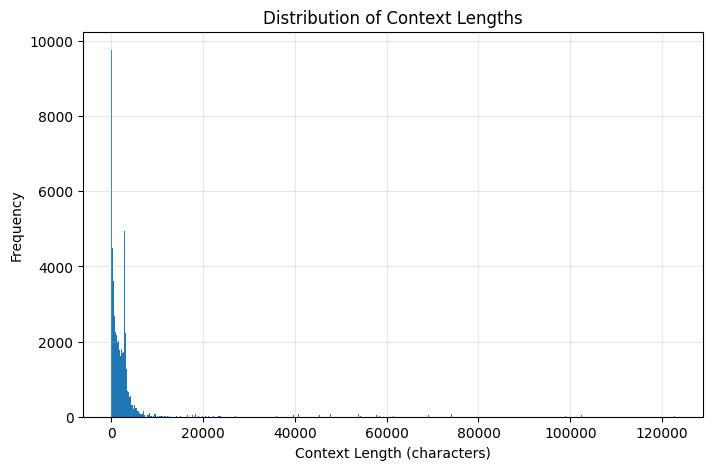

In [11]:
# length of each context row
context_lengths = mrc_df["context"].astype(str).apply(len).tolist()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(context_lengths, bins=1000)
plt.xlabel("Context Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Context Lengths")
plt.grid(alpha=0.3)
# Save the figure
plt.savefig("context_length_distribution_MRCdataset.png", dpi=300, bbox_inches="tight")
plt.show()

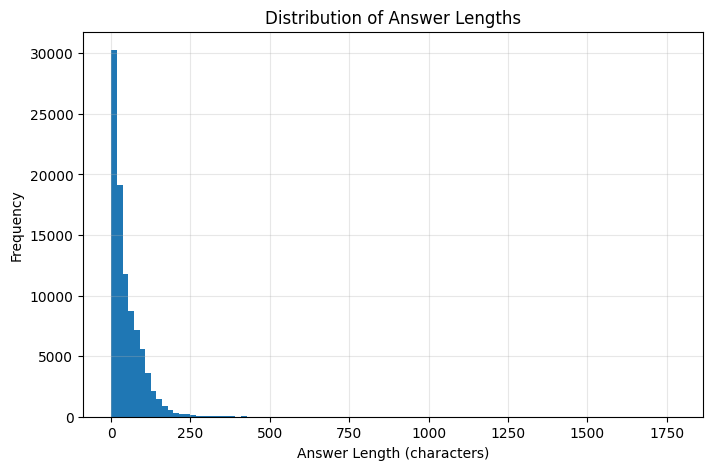

In [12]:
# length of each context row
context_lengths = mrc_df["answer"].astype(str).apply(len).tolist()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(context_lengths, bins=100)
plt.xlabel("Answer Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Answer Lengths")
plt.grid(alpha=0.3)
# Save the figure
#plt.savefig("context_length_distribution_MRCdataset.png", dpi=300, bbox_inches="tight")
plt.show()

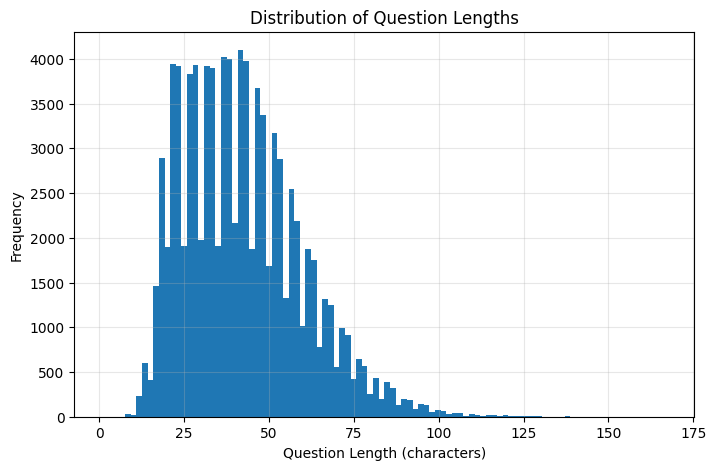

In [13]:
# length of each context row
context_lengths = mrc_df["question"].astype(str).apply(len).tolist()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(context_lengths, bins=100)
plt.xlabel("Question Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Question Lengths")
plt.grid(alpha=0.3)
# Save the figure
#plt.savefig("context_length_distribution_MRCdataset.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
mrc_df[mrc_df["context"].astype(str).str.len() <= 70]

,question,answer,context
1436,ماهي المقاومه؟,الممانعة وعدم الرضوخ لتغيرات وقوى مفروضة من ال...,المقاومة لغة هي الممانعة وعدم الرضوخ لتغيرات و...
10416,ما هي الأماكن السياحية والجذب السياحي الشهيرة ...,.,المضيق هو عبارة عن ممر مائي ضيق يصل بين مسطحين...
23632,ما هي الصعوبات والتحديات التي تواجه المراكب وا...,.,المضيق هو عبارة عن ممر مائي ضيق يصل بين مسطحين...
25454,ما هي العوامل التي تؤدي إلى تشكل المضائق المائ...,.,المضيق هو عبارة عن ممر مائي ضيق يصل بين مسطحين...
29228,ما هي بعض الأمثلة الشهيرة للمضائق المائية في ا...,.,المضيق هو عبارة عن ممر مائي ضيق يصل بين مسطحين...
33933,كيف يؤثر تضييق الممر المائي على حركة المياه وت...,.,المضيق هو عبارة عن ممر مائي ضيق يصل بين مسطحين...
35593,ما هي ولاية البحيرات؟,هي إحدى ولايات جنوب السودان وعاصمتها مدينة رمبيك,ولاية البحيرات هي إحدى ولايات جنوب السودان وعا...
41710,ما هي قائمة خاصة بتكاملات الدوال النسبية؟,.,هذه قائمة خاصة بتكاملات الدوال النسبية:\nالتكا...
45164,ما هي الأثر البيئي والجغرافي للمضائق المائية ع...,.,المضيق هو عبارة عن ممر مائي ضيق يصل بين مسطحين...
55500,ما هو المضيق؟,ممر مائي ضيق يصل بين مسطحين مائيين كبيرين,المضيق هو عبارة عن ممر مائي ضيق يصل بين مسطحين...


###### I note that if the context doesn't contain the answer to the question, the question will be "."

In [15]:
# Strip whitespace
mrc_df["answer"] = mrc_df["answer"].astype(str).str.strip()

# remove answers that are only punctuation like ".", "..", or "..."
mrc_df = mrc_df[~mrc_df["answer"].astype(str).str.fullmatch(r"\.+", na=False)]

# Remove empty strings
mrc_df = mrc_df[mrc_df["answer"] != ""]

# Remove punctuation-only strings
mrc_df = mrc_df[
    ~mrc_df["answer"].str.fullmatch(r"[^\w\u0600-\u06FF0-9٠-٩]+", na=False)
]
# remove rows where the answer is exactly the Arabic comma ،
mrc_df = mrc_df[mrc_df["answer"].str.strip() != "،"]
# Remove single Arabic or English letters
mrc_df = mrc_df[
    ~mrc_df["answer"].str.fullmatch(r"[A-Za-z\u0621-\u064A]", na=False)
]
  

In [16]:
mrc_df[mrc_df["answer"].astype(str).str.len() <= 1]

,question,answer,context
438,كم عدد المباني التخصصية في مجمع الإسماعيلية ال...,9,مجمع الإسماعيلية الطبى هي مجموعة من المراكز ال...
10489,ما هي الأساسيات العامة لأسلوب كتابة لغة السي؟\n,1,"سي أو سِ (، وباللاتينية ""C"")، وهي لغة برمجة حا..."
11254,كم كان عدد أفلام زهير بكير في مجال الإنتاج؟\n,8,زهير بكير مخرج ومؤلف مصري من مواليد 14 أكتوبر ...
17425,في أي مجموعة تقع الهالوجينات في الجدول الدوري؟,7,الهالوجينات هي عناصر أو مواد تشكل املاح باتحاد...
22625,كم عدد مدراء الجات العامين حتى تم تشكيل منظمة ...,5,كان المدير العام للاتفاقية العامة للتعريفات وا...
26220,كم عدد المجموعات العرقية المختلفة التي تعيش في...,7,باك يين هي منطقة جبلية في محافظة سون لا بدولة ...
27170,ما هي المسافة التي ترتفع عن سطح البحر؟\n,1,ميتلاكاتلا هي منطقة سكنية تقع بولاية ألاسكا في...
28685,كم عدد كليات جامعة جهرم للعلوم الطبية؟\n,3,جامعة جهرم للعلوم الطبية (JUMS) هي جامعة حكومي...
36379,كم عدد المهمات التي أطلقتها الهند لاكتشاف القم...,3,شاندريان 3 هي مهمة مخططة ثالثة لاكتشاف القمر م...
45294,ما هي المدن التونسية التي قضى فيها والد أبو ال...,3,أبو القاسم الشَّابِّي الملقب بشاعر الخضراء (24...


###### now, the answer column is cleaned

In [17]:
mrc_df[
    mrc_df["question"]
    .str.replace("؟", "", regex=False)
    .str.replace("\n", " ", regex=False)
    .str.strip()
    .str.split()
    .str.len() == 2
]

,question,answer,context
891,متي ولد؟,1985,إيان جودفيلو أو إيان كودفيلو (من مواليد 1985 أ...
956,من تزوج؟,شفيق جاهان,الجنرال محمد ضياء الحق (12 أغسطس 1924- 17 أغسط...
1436,ماهي المقاومه؟,الممانعة وعدم الرضوخ لتغيرات وقوى مفروضة من ال...,المقاومة لغة هي الممانعة وعدم الرضوخ لتغيرات و...
2642,متي توفي؟,30 مايو 1976,ميتسودو فوتشيدا هو قائد عسكري ياباني ولد في يو...
4810,وأين تتواجد؟,العذراء العظيم.,المجرة هي تجمعات هائلة الحجم تحتوي على مليارات...
5722,متى ولد ؟\n,ولد في 13 أغسطس 1935,ويلهلم إلياسن هو لاعب كرة قدم نرويجي في مركز ،...
6111,"من اخرجه""السياف""؟\n",تشوي جاي هون,فيلم السياف ( ) هو فيلم كوري أكشن من الفترة ال...
8842,أين تقع؟,في سلسلة ألف جزيرة، تنتمي إلى نيويورك,"جزيرة جست روم إناف"""" هي جزيرة تقع في سلسلة ألف..."
10514,أين توفي؟,في سوريا,زياد يوسف منى هو كاتب وباحث وأكاديمي فلسطيني ك...
11357,أين توفي؟,في الزرقاء,عطا الله محمد أبو زياد العيزري (5 يناير 1942 -...


###### There are some questions are not completed and miss the question object. for example
###### أين توفي؟
 ###### انت بتتكلم علي مين في السؤال,كدا السؤال ناقص

In [18]:
mrc_df = mrc_df[
    ~(
        mrc_df["question"]
        .str.replace("؟", "", regex=False)
        .str.replace("\n", " ", regex=False)
        .str.strip()
        .str.split()
        .str.len() == 2
    )
]

In [19]:
mrc_df.shape

(88981, 3)

In [20]:
mrc_df.to_json(
    "mrc-processed.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

In [21]:
with open("mrc-processed.jsonl", "r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline())

{"question":"كيف يتم فرش الحصى في حديقة زن؟\n","answer":"بطريقة خاصة لمحاكاة حركة الماء في المحيطات والبحر وغيرها.","context":"الحديقة أو الحدائق اليابانية (باليابانية: 日本庭園) هي البساتين التي يتم العناية بها في اليابان حسب الطرق التقليدية، وتقوم هذه الطرق على فن خاص يعود تاريخه إلى العهود القديمة. يمكن العثور على هذه الحدائق في بعض البيوت التقليدية اليابانية، في الحدائق العمومية، في المعابد البوذية والمزارات الشنتوية، وفي بعض القصور القديمة. تعتبر حدائق «زن» (مذهب بوذي) الأشهر على الإطلاق في اليابان والعالم.\nالعناصر.\nتتألف الحدائق اليابانية من عدة عناصر وهذه أهمها:\nحديقة زن.\nحديقة زن أو الحديقة الجافة (باليابانية: karesansui == 枯山水 == الطبيعة الناشفة) وأهم ما يميزها هو غياب عنصر الماء، وغالبا ما تتخذ في معابد طائفة زن البوذية. تحاول هذه الحدائق محاكاة الطبيعة ولكن بطريقة تجريدية. يتم تعويض فقدان الماء بوجود الحصى ويتم فرشه بطريقة خاصة لمحاكاة حركة الماء في المحيطات والبحر وغيرها. تنتقى الصخور ذات الأشكال الغريبة وتوضع وسط بساط الحصى، كما تنتشر الطحالب والشجيرات في أرجاءها. تستعمل ب

In [22]:
mrc_df = pd.read_json(
    "mrc-processed.jsonl",
    lines=True
)
mrc_df.head()

,question,answer,context
0,كيف يتم فرش الحصى في حديقة زن؟\n,بطريقة خاصة لمحاكاة حركة الماء في المحيطات وال...,الحديقة أو الحدائق اليابانية (باليابانية: 日本庭園...
1,ما هي الملوثات القديمة الشائعة في البيئة؟\n,العضوية الثابتة، والمعادن الثقيلة أو غيرها من ...,التلوث القديم أو الملوثات القديمة عبارة عن موا...
2,كيف يمكن للأندية المحلية الحصول على عوائد التذ...,تحصل الأندية المحلية على عوائد التذاكر من الات...,إيرادات التذاكر الرياضية (بالإنجليزية: Gate re...
3,ما هي بعض الجوائز التي حصل عليها الفيلم؟,"جائزة ""لولا"" لأفضل فيلم من أكاديمية السينما ال...",بيت الأرواح (بالإنجليزية: The House of the Spi...
4,ما هي الجمعية التي ترأسها نوفاليتش في مدينة غر...,رابطة رجال الأعمال,فاضل نوفاليتش (من مواليد 25 سبتمبر 1959)، هو س...


In [131]:
df_ALRAGE = pd.read_json(
    "ALRAGE-processed.jsonl",
    lines=True
)
df_ALRAGE.head()

,question,context,answer
0,ما هي الدولة التي استثنيها مترنخ عندما قال إن ...,وتم للإخوة اقتسام أوروبا بينهم حين أرسل «مترنخ...,إنجلترا
1,ما هو العصر الذي لم يكن فيه أسلوب أسرة روتشيلد...,لم يَعُد أبناء روتشيلد يملكون زمام المال في أو...,العصر الجديد، عصر الانقلاب الصناعي في أوروبا
2,ما هي العلة التي لم يَعُد بسببها أبناء روتشيلد...,وليست تقتضينا الغاية من هذا الكتاب أن نتعقب تا...,ازدهار الصناعة
3,ما هو دور أسرة روتشيلد في تخفيف ويلات اليهود؟,مات «ماير أنسلم روتشيلد» عام ١٨١٢م، وخلَّف ورا...,كانوا أوائل من دعموا اليهود، وحاولوا تخفيف ويل...
4,ما هو تأثير أسرة روتشيلد على العصر الجديد؟,وكان «جيمس» قد أنشأ في الوقت نفسه مصرفًا في با...,خلقوا مبدأ الشرف في الأمور المالية، وابتكروا أ...


## hsseinmz/arcd

In [6]:
splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'validation': 'plain_text/validation-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/hsseinmz/arcd/" + splits["train"])

In [11]:
df_train.head()

,id,title,context,question,answers
0,969331847966,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- من هو جمال أحمد حمزة خاشقجي؟,"{'text': ['صحفي وإعلامي'], 'answer_start': [73]}"
1,115150665555,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- متى ولد جمال أحمد حمزة خاشقجي وتوفي؟ ال,{'text': ['حمزة خاشقجي (13 أكتوبر 1958، المدين...
2,74212080718,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- في أي مدينة ولد جمال أحمد حمزة خاشقجي؟ ال,"{'text': ['المدينة المنورة'], 'answer_start': ..."
3,465699296586,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- في أي صحيفة قام بكتابة عمود منذ عام 2017؟ ال,"{'text': ['واشنطن بوست'], 'answer_start': [224]}"
4,564177542570,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- كيف وصفها في الصحف ووسائل الإعلام الدولية؟ ال,{'text': ['وُصف في الصحف وأجهزة الاعلام العالم...


In [8]:
import pandas as pd

splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'validation': 'plain_text/validation-00000-of-00001.parquet'}
df_validation = pd.read_parquet("hf://datasets/hsseinmz/arcd/" + splits["validation"])

In [10]:
df_validation.head()

,id,title,context,question,answers
0,621723207492,حمزة بن عبد المطلب,حمزة بن عبد المطلب الهاشمي القرشي صحابي من صحا...,من هو حمزة بن عبد المطلب؟,{'text': ['صحابي من صحابة رسول الإسلام محمد، و...
1,189105393656,حمزة بن عبد المطلب,حمزة بن عبد المطلب الهاشمي القرشي صحابي من صحا...,بما وصفه رسول الله؟,"{'text': ['وَخَيْرُ أَعْمَامِي'], 'answer_star..."
2,662616978980,حمزة بن عبد المطلب,حمزة بن عبد المطلب الهاشمي القرشي صحابي من صحا...,بما وصف رسول الله على ؟,"{'text': ['«خَيْرُ إِخْوَتِي عَلِيٌّ،'], 'answ..."
3,50146585922,حمزة بن عبد المطلب,أسلم حمزة في السنة الثانية من بعثة النبي محمد،...,متى اسلم حمزة؟,{'text': ['في السنة الثانية من بعثة النبي محمد...
4,259563807541,حمزة بن عبد المطلب,أسلم حمزة في السنة الثانية من بعثة النبي محمد،...,و ماذا فعل فى غزوة بدر؟,{'text': ['وقَتَلَ فيها شيبة بن ربيعة مبارزةً،...


In [19]:
# Merge the datasets
df_arcd = pd.concat([df_train, df_validation], ignore_index=True)

# Check the size
print(f"Number of rows: {len(df_arcd)}")
# Save as CSV
df_arcd.to_csv(
    "arcd.csv",
    index=False,
    encoding="utf-8-sig"
)

Number of rows: 1395


In [132]:
df_arcd = pd.read_csv("arcd.csv", encoding="utf-8-sig")
df_arcd.head()

,id,title,context,question,answers
0,969331847966,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- من هو جمال أحمد حمزة خاشقجي؟,"{'text': array(['صحفي وإعلامي'], dtype=object)..."
1,115150665555,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- متى ولد جمال أحمد حمزة خاشقجي وتوفي؟ ال,{'text': array(['حمزة خاشقجي (13 أكتوبر 1958، ...
2,74212080718,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- في أي مدينة ولد جمال أحمد حمزة خاشقجي؟ ال,"{'text': array(['المدينة المنورة'], dtype=obje..."
3,465699296586,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- في أي صحيفة قام بكتابة عمود منذ عام 2017؟ ال,"{'text': array(['واشنطن بوست'], dtype=object),..."
4,564177542570,جمال خاشقجي,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,- كيف وصفها في الصحف ووسائل الإعلام الدولية؟ ال,{'text': array(['وُصف في الصحف وأجهزة الاعلام ...


In [133]:
df_arcd.rename(columns={"answers": "answer"}, inplace=True)
df_arcd=df_arcd[["question","context","answer"]]
df_arcd.head()

,question,context,answer
0,- من هو جمال أحمد حمزة خاشقجي؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,"{'text': array(['صحفي وإعلامي'], dtype=object)..."
1,- متى ولد جمال أحمد حمزة خاشقجي وتوفي؟ ال,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,{'text': array(['حمزة خاشقجي (13 أكتوبر 1958، ...
2,- في أي مدينة ولد جمال أحمد حمزة خاشقجي؟ ال,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,"{'text': array(['المدينة المنورة'], dtype=obje..."
3,- في أي صحيفة قام بكتابة عمود منذ عام 2017؟ ال,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,"{'text': array(['واشنطن بوست'], dtype=object),..."
4,- كيف وصفها في الصحف ووسائل الإعلام الدولية؟ ال,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,{'text': array(['وُصف في الصحف وأجهزة الاعلام ...


In [134]:
import re

def extract_answer(x):
    if isinstance(x, dict):
        return x["text"][0] if len(x["text"]) else None

    if isinstance(x, str):
        match = re.search(r"array\(\['(.*?)'\]", x)
        if match:
            return match.group(1)
        return x  # Already plain text

    return None

df_arcd["answer"] = df_arcd["answer"].apply(extract_answer)

In [135]:
df_arcd.head(20)

,question,context,answer
0,- من هو جمال أحمد حمزة خاشقجي؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,صحفي وإعلامي
1,- متى ولد جمال أحمد حمزة خاشقجي وتوفي؟ ال,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,حمزة خاشقجي (13 أكتوبر 1958، المدينة المنورة -...
2,- في أي مدينة ولد جمال أحمد حمزة خاشقجي؟ ال,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,المدينة المنورة
3,- في أي صحيفة قام بكتابة عمود منذ عام 2017؟ ال,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,واشنطن بوست
4,- كيف وصفها في الصحف ووسائل الإعلام الدولية؟ ال,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,"وُصف في الصحف وأجهزة الاعلام العالمية بأنه ""وف..."
5,- في أي منصب شغل في الجريدة؟ ال,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,وتقلّد منصب مستشار،
6,- متى غادر خاشقجي السعودية؟ ال,غادر خاشقجي السعودية في سبتمبر 2017، وكتب بعد ...,في سبتمبر 2017،
7,- لمن ينتقده في مقالاته الإخبارية؟ ال,غادر خاشقجي السعودية في سبتمبر 2017، وكتب بعد ...,الحكومة السعودية.
8,- لمن انتقد خاشقجي بشدة في مقالاته الإخبارية؟ ال,غادر خاشقجي السعودية في سبتمبر 2017، وكتب بعد ...,ولي العهد السعودي محمد بن سلمان، والملك سلمان ...
9,- أي دولة هي أكبر دولة في الشرق الأوسط؟ ال,السعودية أو (رسميًا: المملكة العربية السعودية)...,المملكة العربية السعودية)


In [136]:
df_arcd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1395 non-null   object
 1   context   1395 non-null   object
 2   answer    1395 non-null   object
dtypes: object(3)
memory usage: 32.8+ KB


In [137]:
# number of null values in each column
df_arcd.isnull().sum()



question    0
context     0
answer      0
dtype: int64

In [138]:
# number of duplicates rows
df_arcd.duplicated().sum()


0

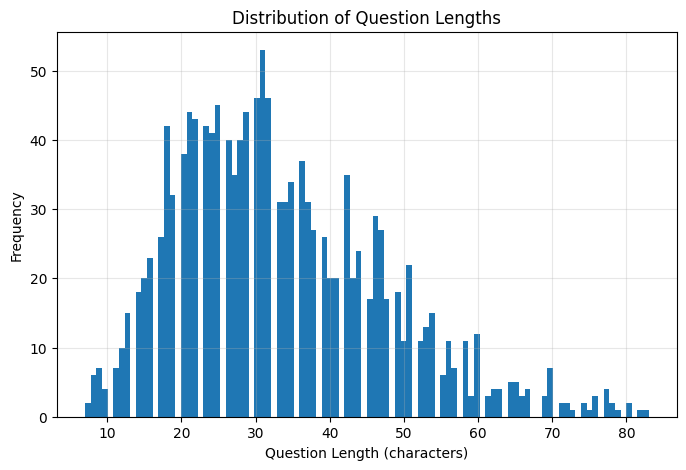

In [139]:
# length of each context row
context_lengths = df_arcd["question"].astype(str).apply(len).tolist()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(context_lengths, bins=100)
plt.xlabel("Question Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Question Lengths")
plt.grid(alpha=0.3)
# Save the figure
#plt.savefig("context_length_distribution_MRCdataset.png", dpi=300, bbox_inches="tight")
plt.show()



In [140]:
df_arcd[df_arcd["question"].astype(str).str.len() <= 10]

,question,context,answer
235,متى توفيَ؟,السيّد عُمر بن مختار بن عُمر المنفي الهلالي (2...,16 سبتمبر 1931)،
433,متى اسست؟,نادي الهلال السعودي هو نادٍ رياضيّ، ثقافيّ، ا...,1957،
443,من العرب؟,العرب فرع من فروع الشعوب السامية تتركز أساسًا ...,فرع من فروع الشعوب السامية
532,اين ولد؟,العربي بن مهيدي أحد شهداء الثورة الجزائرية، كا...,في مدينة عين مليلة الواقعة في شرق الجزائر،
559,من رسمها؟,الموناليزا (باللُغةِ الفرنسيةِ: Mona Lisa، وبا...,ليوناردو دا فينشي،
560,متى رسمها؟,الموناليزا (باللُغةِ الفرنسيةِ: Mona Lisa، وبا...,خلال عصر النهضة الإيطالية.
581,متى اصدرت؟,) هي عملة معماة ونظام دفع عالمي يمكن مقارنتها ...,"وأُصدِر كبرنامج مفتوح المصدر في عام 2009.""\'"
985,وماذا قال؟,كان أصغر أعضاء المجلس الأعلى للقوات المسلحة سن...,أنها مبررة؛
1009,متى ولد؟,محمد رمضان (23 مايو 1988 -)، ممثل ومغني مصري. ...,(23 مايو 1988
1018,من انشأه,التقويم الهجري القمري أو التقويم الإسلامي هو ت...,الخليفة عمر بن الخطاب


In [141]:
import re

def clean_question(text):
    text = str(text).strip()

    # Remove leading bullets/dashes
    text = re.sub(r'^\s*[-•*]+\s*', '', text)

    # Keep only up to the first Arabic or English question mark
    m = re.search(r'[؟?]', text)
    if m:
        text = text[:m.end()]

    return text.strip()

df_arcd["question"] = df_arcd["question"].apply(clean_question)

In [142]:
df_arcd = df_arcd[
    ~(
        df_arcd["question"]
        .str.replace("؟", "", regex=False)
        .str.replace("\n", " ", regex=False)
        .str.strip()
        .str.split()
        .str.len() == 2
    )
]

In [143]:
df_arcd[df_arcd["question"].astype(str).str.len() <= 15]

,question,context,answer
18,أين تقع مصر؟,مِصرَ أو (رسمياً: جُمهورِيّةُ مِصرَ العَرَبيّة...,تقع في الركن الشمالي الشرقي من قارة أفريقيا،
34,متى فقد أمه؟,وُلد في مكة في شهر ربيع الأول من عام الفيل قبل...,أمه في سنّ مبكرة
36,أين يقع المغرب؟,المَغْرِب أو (رسمياً: المَمْلَكَةُ المَغْرِبِي...,تقع في أقصى غرب شمال أفريقيا
144,اين تقع فلسطين؟,فلسطين (بالعبرية: פלשתינה أو פלסטין حسب السياق...,في غرب آسيا
152,ما شكل فلسطين؟,عقب الحرب العالمية الأولى وتبعاتها من سقوط الد...,مستطيلة الشكل
...,...,...,...
1242,من هم الدروز؟,الدروز يسمون أنفسهم الموحدون هم عرقية دينية با...,هم عرقية دينية باطنية تدين بمذهب التوحيد ذو ال...
1246,كم عدد الدروز؟,المذهب الدرزي هو واحد من الجماعات الدينية الكب...,حوالي 1.5 مليون نسمة.
1251,ما هو السرطان,السرطان (بالإنجليزية: Cancer) هو مجموعة من الأ...,هو نمو الخلايا وانتشارها بشكل لا يمكن التحكّم ...
1253,كيف يمكن علاجه؟,السرطان (بالإنجليزية: Cancer) هو مجموعة من الأ...,عن طريق الجراحة أو المعالجة الإشعاعية أو المعا...


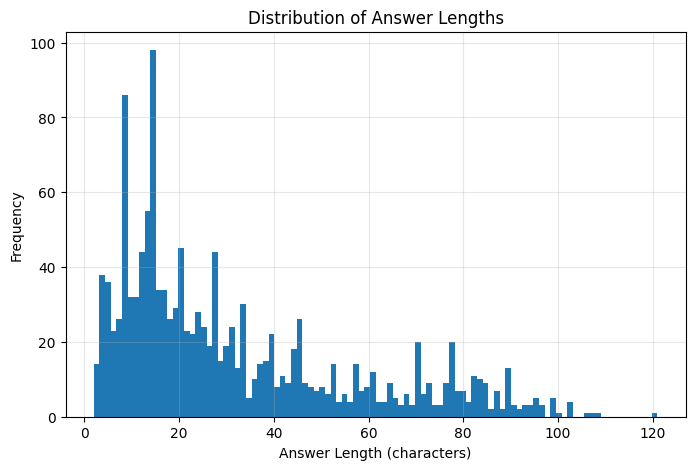

In [144]:

# length of each context row
context_lengths = df_arcd["answer"].astype(str).apply(len).tolist()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(context_lengths, bins=100)
plt.xlabel("Answer Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Answer Lengths")
plt.grid(alpha=0.3)
# Save the figure
#plt.savefig("context_length_distribution_MRCdataset.png", dpi=300, bbox_inches="tight")
plt.show()




In [145]:
df_arcd[df_arcd["answer"].astype(str).str.len() <= 2]

,question,context,answer
171,ما اسم الصين فى اللغة الصينية؟,الصين (بالصينية المبسطة: 中国 تشونغوا؛ بالصينية ...,中国
316,ماهو عنوان أول ألبوم فردي أصدره ثامر حسني؟,تامر حسني (16 أغسطس 1977 -) هو مغني وملحن وممث...,-)
1111,كم عدد ولايات الهند؟,على الصعيد الإداري تعد الهند جمهورية فيدرالية،...,28


In [146]:
# remove row number 316, because the answer uncorrect
df_arcd.drop(index=316, inplace=True)

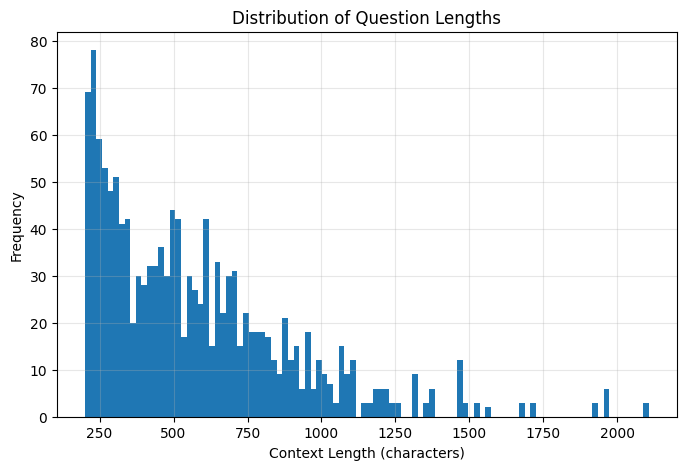

In [147]:

# length of each context row
context_lengths = df_arcd["context"].astype(str).apply(len).tolist()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(context_lengths, bins=100)
plt.xlabel("Context Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Question Lengths")
plt.grid(alpha=0.3)
# Save the figure
#plt.savefig("context_length_distribution_MRCdataset.png", dpi=300, bbox_inches="tight")
plt.show()


In [148]:

df_arcd[df_arcd["context"].astype(str).str.len() <= 205]


,question,context,answer
0,من هو جمال أحمد حمزة خاشقجي؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,صحفي وإعلامي
1,متى ولد جمال أحمد حمزة خاشقجي وتوفي؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,حمزة خاشقجي (13 أكتوبر 1958، المدينة المنورة -...
2,في أي مدينة ولد جمال أحمد حمزة خاشقجي؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,المدينة المنورة
54,ما هو عدد الولايات في الولايات المتحدة الأمريكية؟,الوِلَايَات المُتَّحِدَة الأَمرِيكِيَّة (2) (ب...,خمسِين وِلاية
55,ما هي ترجمة الولايات المتحدة الأمريكية بالإنجل...,الوِلَايَات المُتَّحِدَة الأَمرِيكِيَّة (2) (ب...,United States of America
56,ما هو نظام الولايات المتحدة الأمريكية الحكومي؟,الوِلَايَات المُتَّحِدَة الأَمرِيكِيَّة (2) (ب...,جُمهُورِيّة دُستُورِيّة اِتِّحادِيّة(1)
333,من هو صاحب مشروع عجائب الدنيا السبع؟,عجائب الدنيا السبع الجديدة، هو مشروع استثماري ...,منتج أفلام كندي من أصل سويسري يدعى برنارد فيبر
334,متى تم إطلاق مشروع عجائب الدنيا السبع؟,عجائب الدنيا السبع الجديدة، هو مشروع استثماري ...,عام 1999،
335,ماهي الشركة التي تبنت مشروع عجائب الدنيا السبع؟,عجائب الدنيا السبع الجديدة، هو مشروع استثماري ...,العالم المفتوح الجديد (New Open World Corporat...
657,بماذا تسمى متلازمة داون؟,متلازمة داون أو تناذر داون أو التثالث الصبغي ...,تناذر داون أو التثالث الصبغي 21 أو التثالث الص...


In [149]:
print("context 0 :",df_arcd["context"][0])

print("qestion 0: ",df_arcd["question"][0])

print("answer 0: ",df_arcd["answer"][0])


context 0 : جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة المنورة - 2 أكتوبر 2018)، صحفي وإعلامي سعودي، رأس عدّة مناصب لعدد من الصحف في السعودية، وتقلّد منصب مستشار، كما أنّه مدير عام قناة العرب الإخبارية سابقًا.
qestion 0:  من هو جمال أحمد حمزة خاشقجي؟
answer 0:  صحفي وإعلامي


In [150]:

df_arcd.to_json(
    "arcd-processed.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

In [151]:
df_arcd = pd.read_json(
    "arcd-processed.jsonl",
    lines=True
)
df_arcd.head()

,question,context,answer
0,من هو جمال أحمد حمزة خاشقجي؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,صحفي وإعلامي
1,متى ولد جمال أحمد حمزة خاشقجي وتوفي؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,حمزة خاشقجي (13 أكتوبر 1958، المدينة المنورة -...
2,في أي مدينة ولد جمال أحمد حمزة خاشقجي؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,المدينة المنورة
3,في أي صحيفة قام بكتابة عمود منذ عام 2017؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,واشنطن بوست
4,كيف وصفها في الصحف ووسائل الإعلام الدولية؟,جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة...,"وُصف في الصحف وأجهزة الاعلام العالمية بأنه ""وف..."


## ArQuAD

In [2]:
import pandas as pd

train_df_ArQuAD = pd.read_csv("./ArQuAD/ArQuAD-train.csv", encoding="cp1256")
print(train_df_ArQuAD.shape)
train_df_ArQuAD.head()

(12816, 6)


,context,question,answer_start,text,title,id
0,يوتيوب هو موقع ويب يسمح لمستخدميه برفع التسجيل...,متى تم تاسيس يوتيوب؟,144,14 فبراير سنة 2005م,يوتيوب,392437462908
1,يوتيوب هو موقع ويب يسمح لمستخدميه برفع التسجيل...,بكم موظف يعمل يوتيوب حاليا؟,473,بأكثر من ألفي موظف,يوتيوب,498210546774
2,يوتيوب هو موقع ويب يسمح لمستخدميه برفع التسجيل...,ما هي التقنية المستخدمة في يوتيوب لعرض الفيديو...,268,تقنية برنامج أدوبي فلاش,يوتيوب,437027335293
3,يوتيوب هو موقع ويب يسمح لمستخدميه برفع التسجيل...,بكم بيع يوتيوب لشركة Google؟,562,1.65 مليار دولار أمريكي,يوتيوب,865492214275
4,أسس موقع يوتيوب تشاد هيرلي وستيف تشين وجاود كر...,من أنشأ موقع يوتيوب؟,16,تشاد هيرلي وستيف تشين وجاود كريم,يوتيوب,719905160468


In [3]:
train_df_ArQuAD.rename(columns={"text": "answer"}, inplace=True)
train_df_ArQuAD=train_df_ArQuAD[["question","context","answer"]]
train_df_ArQuAD.head()


,question,context,answer
0,متى تم تاسيس يوتيوب؟,يوتيوب هو موقع ويب يسمح لمستخدميه برفع التسجيل...,14 فبراير سنة 2005م
1,بكم موظف يعمل يوتيوب حاليا؟,يوتيوب هو موقع ويب يسمح لمستخدميه برفع التسجيل...,بأكثر من ألفي موظف
2,ما هي التقنية المستخدمة في يوتيوب لعرض الفيديو...,يوتيوب هو موقع ويب يسمح لمستخدميه برفع التسجيل...,تقنية برنامج أدوبي فلاش
3,بكم بيع يوتيوب لشركة Google؟,يوتيوب هو موقع ويب يسمح لمستخدميه برفع التسجيل...,1.65 مليار دولار أمريكي
4,من أنشأ موقع يوتيوب؟,أسس موقع يوتيوب تشاد هيرلي وستيف تشين وجاود كر...,تشاد هيرلي وستيف تشين وجاود كريم


In [5]:

test_df_ArQuAD = pd.read_csv("./ArQuAD/ArQuAD-test.csv", encoding="cp1256")
print(test_df_ArQuAD.shape)
test_df_ArQuAD.head()


(1608, 6)


,context,question,answer_start,text,title,id
0,الاضطراب الوسواسي القهري (أو اختصاراً الوسواس ...,ما هو الاضطراب النّفسيّ الذي يشعر المصاب به أن...,38,الوسواس القهري,اضطراب وسواسي قهري,726092190738
1,الاضطراب الوسواسي القهري (أو اختصاراً الوسواس ...,بماذا يعرّف الوسواس القهري ؟,377,فكر متسلّط وسلوك جبري يظهر بتكرار لدى الفرد,اضطراب وسواسي قهري,730224951479
2,الاضطراب الوسواسي القهري (أو اختصاراً الوسواس ...,بماذا يشعر المصاب بالوسواس القهري إذا قاوم الأ...,498,بالقلق والتوتر,اضطراب وسواسي قهري,563168204176
3,الاضطراب الوسواسي القهري (أو اختصاراً الوسواس ...,ما المقياس الذي يُستخدم لقياس حدّة الاضطراب ال...,1460,مقياس ييل-براون,اضطراب وسواسي قهري,10590799805
4,يصيب الاضطراب الوسواسي القهري حوالي 2.3% من ال...,كم تبلغ نسبة الأشخاص الذين يصابون بالوسواس الق...,30,حوالي 2.3%,اضطراب وسواسي قهري,780867293212


In [6]:

test_df_ArQuAD.rename(columns={"text": "answer"}, inplace=True)
test_df_ArQuAD=test_df_ArQuAD[["question","context","answer"]]
test_df_ArQuAD.head()


,question,context,answer
0,ما هو الاضطراب النّفسيّ الذي يشعر المصاب به أن...,الاضطراب الوسواسي القهري (أو اختصاراً الوسواس ...,الوسواس القهري
1,بماذا يعرّف الوسواس القهري ؟,الاضطراب الوسواسي القهري (أو اختصاراً الوسواس ...,فكر متسلّط وسلوك جبري يظهر بتكرار لدى الفرد
2,بماذا يشعر المصاب بالوسواس القهري إذا قاوم الأ...,الاضطراب الوسواسي القهري (أو اختصاراً الوسواس ...,بالقلق والتوتر
3,ما المقياس الذي يُستخدم لقياس حدّة الاضطراب ال...,الاضطراب الوسواسي القهري (أو اختصاراً الوسواس ...,مقياس ييل-براون
4,كم تبلغ نسبة الأشخاص الذين يصابون بالوسواس الق...,يصيب الاضطراب الوسواسي القهري حوالي 2.3% من ال...,حوالي 2.3%


In [7]:

dev_df_ArQuAD = pd.read_csv("./ArQuAD/ArQuAD-dev.csv", encoding="cp1256")
print(dev_df_ArQuAD.shape)
dev_df_ArQuAD.head()


(1596, 6)


,context,question,answer_start,text,title,id
0,تميز علوم الأرض عمومًا بين أربعة أغلفة وهي الغ...,كم غلافاً في الطبيعة ؟,27,أربعة أغلفة,بيئة طبيعية,137041983642
1,تميز علوم الأرض عمومًا بين أربعة أغلفة وهي الغ...,ما هي العلوم التي يشملها علم الأرض ؟,486,الجغرافيا والجيولوجيا والجيوفيزياء وعلم تقسيم ...,بيئة طبيعية,177188853797
2,تميز علوم الأرض عمومًا بين أربعة أغلفة وهي الغ...,ما هو الغلاف الذي يضيفه بعض علماء الأرض كجزء م...,187,الغلاف الجليدي,بيئة طبيعية,776391090586
3,تميز علوم الأرض عمومًا بين أربعة أغلفة وهي الغ...,ماذا يشمل علم الأرض ؟,404,كافة العلوم المتعلقة بكوكب الأرض,بيئة طبيعية,544146058837
4,إن قشرة الأرض، أو الغلاف الصخري، هي السطح الخا...,ما الاسم العلمي لقشرة الأرض ؟,18,الغلاف الصخري,بيئة طبيعية,493236404992


In [8]:

dev_df_ArQuAD.rename(columns={"text": "answer"}, inplace=True)
dev_df_ArQuAD=dev_df_ArQuAD[["question","context","answer"]]
dev_df_ArQuAD.head()


,question,context,answer
0,كم غلافاً في الطبيعة ؟,تميز علوم الأرض عمومًا بين أربعة أغلفة وهي الغ...,أربعة أغلفة
1,ما هي العلوم التي يشملها علم الأرض ؟,تميز علوم الأرض عمومًا بين أربعة أغلفة وهي الغ...,الجغرافيا والجيولوجيا والجيوفيزياء وعلم تقسيم ...
2,ما هو الغلاف الذي يضيفه بعض علماء الأرض كجزء م...,تميز علوم الأرض عمومًا بين أربعة أغلفة وهي الغ...,الغلاف الجليدي
3,ماذا يشمل علم الأرض ؟,تميز علوم الأرض عمومًا بين أربعة أغلفة وهي الغ...,كافة العلوم المتعلقة بكوكب الأرض
4,ما الاسم العلمي لقشرة الأرض ؟,إن قشرة الأرض، أو الغلاف الصخري، هي السطح الخا...,الغلاف الصخري


In [9]:

# concatenate all ArQuAD datasets
ArQuAD_df=pd.concat([train_df_ArQuAD,test_df_ArQuAD,dev_df_ArQuAD],ignore_index=True)
ArQuAD_df = ArQuAD_df.sample(frac = 1,random_state=random_state).reset_index(drop=True)
print(ArQuAD_df.shape)
ArQuAD_df.head()




(16020, 3)


,question,context,answer
0,ماذا يُكنى موسى بن جعفر الكاظم؟,موسى بن جعفر الكاظم ( 7 صفر 128ه ـ-25 رجب 183ه...,أبو إبراهيم وأبو الحسن
1,كم عدد امارات المناطق التي تقع تحت مسؤولية وزا...,وزارة الداخلية السعودية هي الوزارة المسؤولة عن...,13
2,ماذا تسمى الخطوط الافقية في المصفوفة؟,تدعى الخطوط الأفقية في المصفوفة بالأسطر بينما ...,بالأسطر
3,من عبد العزيز بوتفليقة؟,عبد العزيز بوتفليقة (2 مارس 1937، وجدة -)، الر...,الرئيس العاشر للجزائر منذ التكوين
4,ما الاسم الرسمي لدولة اليمن ؟,اليَمَن أو (رسمياً: الجُمْهُوْرِيَّةُ اليَمَنِ...,الجُمْهُوْرِيَّةُ اليَمَنِيَّة


In [10]:
ArQuAD_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16020 entries, 0 to 16019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  16020 non-null  object
 1   context   16020 non-null  object
 2   answer    16020 non-null  object
dtypes: object(3)
memory usage: 375.6+ KB


In [11]:
# number of duplicates rows
ArQuAD_df.duplicated().sum()

0

In [12]:
# number of null values in each column
ArQuAD_df.isnull().sum()

question    0
context     0
answer      0
dtype: int64

In [13]:
# number of duplicates rows
#ArQuAD_df.duplicated().sum()

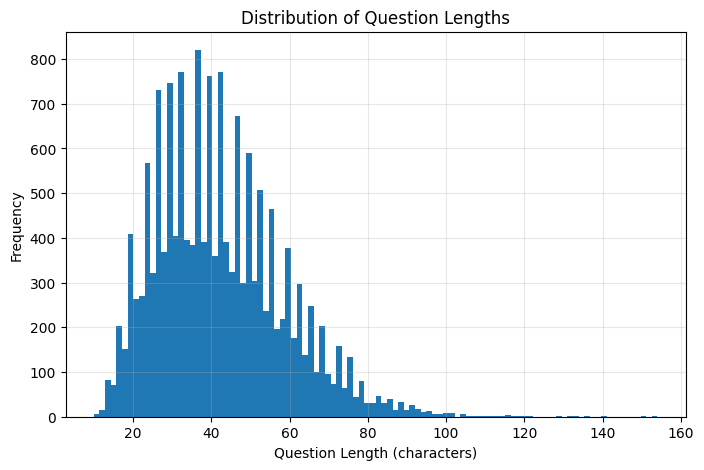

In [14]:

# length of each context row
context_lengths = ArQuAD_df["question"].astype(str).apply(len).tolist()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(context_lengths, bins=100)
plt.xlabel("Question Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Question Lengths")
plt.grid(alpha=0.3)
# Save the figure
#plt.savefig("context_length_distribution_MRCdataset.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:

ArQuAD_df[ArQuAD_df["question"].astype(str).str.len() <= 10]


,question,context,answer
4224,من الشيعة؟,الشيعة هو اسم يطلق على ثاني أكبر طائفة من المس...,ثاني أكبر طائفة من المسلمين


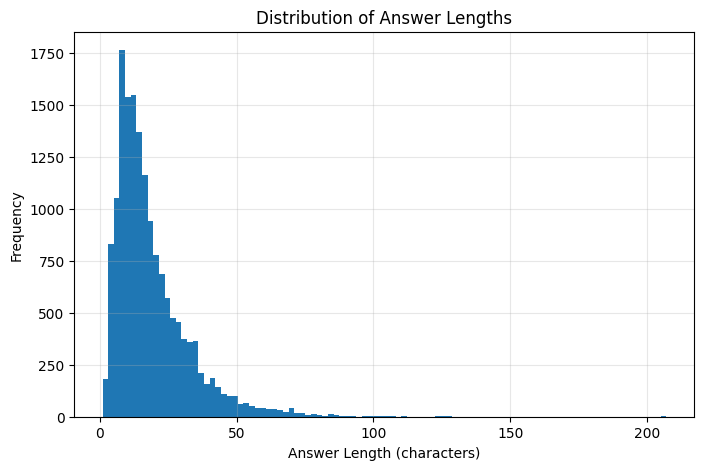

In [16]:

# length of each context row
context_lengths = ArQuAD_df["answer"].astype(str).apply(len).tolist()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(context_lengths, bins=100)
plt.xlabel("Answer Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Answer Lengths")
plt.grid(alpha=0.3)
# Save the figure
#plt.savefig("context_length_distribution_MRCdataset.png", dpi=300, bbox_inches="tight")
plt.show()


In [17]:
ArQuAD_df[ArQuAD_df["answer"].astype(str).str.len() <= 1]

,question,context,answer
418,ما الحرف الذي تم اعتماده للاستخدام الكني والفن...,وقد تم تصميم برج خليفة من طرف أدريان سميث ثم م...,Y
5787,كم عدد الإنجازات التي حققها عصام الحضري على ال...,عصام الدين كمال توفيق الحضري، (ولد في 15 يناير...,6
7048,كم مجموعة علميّة يضمّ المعهد الفنيّ المصري حال...,أثناء إعادة بناء القوات المسلحة المصرية بعد حر...,9
8469,كم عدد الجوائز التي حصل عليها كرانستون عن فئة ...,حاز المسلسل على 16 جائزة إيمي، من بينها 4 انتص...,4
9242,كم معبد يقع تحت سيطرة اليهود في أذربيجان؟,وصل الإسلام إلى أذربيجان من خلال العرب في القر...,3
11588,كم عضواً في أوبك من إفريقيا ؟,اعتباراً من يناير 2019، تملك أوبك 11 عضواً، 4 ...,5
15610,ما مرتبة مسلسل فريندز من بين أفضل 50 برنامج تل...,"تلقى ""فريندز"" إشادة في جميع مواسمه، ليصبح واحد...",7


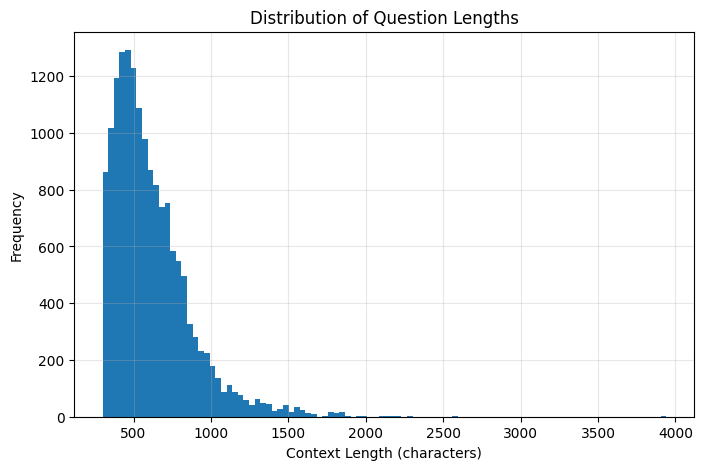

In [18]:

# length of each context row
context_lengths = ArQuAD_df["context"].astype(str).apply(len).tolist()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(context_lengths, bins=100)
plt.xlabel("Context Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Question Lengths")
plt.grid(alpha=0.3)
# Save the figure
#plt.savefig("context_length_distribution_MRCdataset.png", dpi=300, bbox_inches="tight")
plt.show()


In [19]:
ArQuAD_df[ArQuAD_df["context"].astype(str).str.len() <= 300]

,question,context,answer
199,من الفريق المنافس للمنتخب الفرنسي في نهائي كأس...,بطولة كأس العالم من أكثر الأحداث الرياضية مشاه...,المنتخب الكرواتي
240,لماذا رسى البحارة السفينة على ظهر الحوت؟,يهرب سندباد ويبحر مع عمه علي، لكنه ينفصل عن عم...,ظناً من البحارة أنه جزيرة
1616,متى وقع زلزال هايتي؟,كان ووكر يقيم في سانتا باربرا بولاية كاليفورني...,عام 2010
4788,اذكر أمثلة على المخلوقات الغريبة التي واجهها س...,يهرب سندباد ويبحر مع عمه علي، لكنه ينفصل عن عم...,طائر العنقاء العملاق والمارد العملاق ذا اللون ...
4838,متى عمل صالح ككاتب صحفي في مجلة اقتصاد؟,قبل أن يتلحق صالح للتحرير في جريدة الوطن، كان ...,في الفترة ما بين 1424 ـ 1425
5603,على أي مذهب نشأ بول ووكر؟,كان ووكر يقيم في سانتا باربرا بولاية كاليفورني...,المذهب المورموني
7042,مع من هرب سندباد و أبحر؟,يهرب سندباد ويبحر مع عمه علي، لكنه ينفصل عن عم...,مع عمه علي
8107,كم شخص تابع المباراة النهائية لكأس العالم 2006؟,بطولة كأس العالم من أكثر الأحداث الرياضية مشاه...,715 مليون شخص
9063,من الفريق الذي فاز ببطولة كأس العالم 2018؟,بطولة كأس العالم من أكثر الأحداث الرياضية مشاه...,المنتخب الفرنسي
10042,مع من كان يعيش ووكر في كاليفورنيا؟,كان ووكر يقيم في سانتا باربرا بولاية كاليفورني...,مع كلبيه


In [20]:
print("context 23 :",ArQuAD_df["context"][23])

print("qestion 23: ",ArQuAD_df["question"][23])

print("answer 23: ",ArQuAD_df["answer"][23])


context 23 : الخديوي توفيق (15 نوفمبر 1852 - 7 يناير 1892)، سادس حكام مصر من الأسرة العلوية. هو محمد توفيق بن إسماعيل بن إبراهيم باشا بن محمد علي باشا، وهو الابن الأكبر للخديوي إسماعيل من مستولدته شفق نور هانم التي لم تكن ضمن زوجاته الأربع، وربما يكون ذلك سبب عدم إرساله مع باقي أبنائه للدراسة في أوروبا، كما يفسر ذلك العلاقة السيئة بينه وبين أبيه والتي تجلت بعد عزل إسماعيل في نأيه عنه وإقصاء كل رجاله.
qestion 23:  من هو الابن الأكبر للخديوي إسماعيل؟
answer 23:  الخديوي توفيق


In [21]:
ArQuAD_df.to_json(
    "ArQuAD-processed.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

In [22]:
ArQuAD_df = pd.read_json(
    "ArQuAD-processed.jsonl",
    lines=True
)
ArQuAD_df.head()

,question,context,answer
0,ماذا يُكنى موسى بن جعفر الكاظم؟,موسى بن جعفر الكاظم ( 7 صفر 128ه ـ-25 رجب 183ه...,أبو إبراهيم وأبو الحسن
1,كم عدد امارات المناطق التي تقع تحت مسؤولية وزا...,وزارة الداخلية السعودية هي الوزارة المسؤولة عن...,13
2,ماذا تسمى الخطوط الافقية في المصفوفة؟,تدعى الخطوط الأفقية في المصفوفة بالأسطر بينما ...,بالأسطر
3,من عبد العزيز بوتفليقة؟,عبد العزيز بوتفليقة (2 مارس 1937، وجدة -)، الر...,الرئيس العاشر للجزائر منذ التكوين
4,ما الاسم الرسمي لدولة اليمن ؟,اليَمَن أو (رسمياً: الجُمْهُوْرِيَّةُ اليَمَنِ...,الجُمْهُوْرِيَّةُ اليَمَنِيَّة
